In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
# Load datasets

scheme_df = pd.read_csv("07_scheme_performance.csv")
investor_df = pd.read_csv("08_investor_transactions.csv")
holding_df = pd.read_csv("09_portfolio_holdings.csv")
benchmark_df = pd.read_csv("10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
print("Scheme Performance")
display(scheme_df.head())

print("\nInvestor Transactions")
display(investor_df.head())

print("\nPortfolio Holdings")
display(holding_df.head())

print("\nBenchmark Indices")
display(benchmark_df.head())

Scheme Performance


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low



Investor Transactions


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending



Portfolio Holdings


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31



Benchmark Indices


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [4]:
# VaR & CVaR Calculation

var_cvar_report = pd.DataFrame()

var_cvar_report['amfi_code'] = scheme_df['amfi_code']
var_cvar_report['scheme_name'] = scheme_df['scheme_name']

# Using 1-Year Return as return distribution proxy
var_cvar_report['VaR_95'] = scheme_df['return_1yr_pct'] * 0.95

# Simple CVaR approximation
var_cvar_report['CVaR_95'] = scheme_df['return_1yr_pct'] * 0.90

var_cvar_report.head()

,amfi_code,scheme_name,VaR_95,CVaR_95
0,119551,SBI Bluechip Fund - Regular Plan - Growth,11.7990,11.178
1,119552,SBI Bluechip Fund - Direct Plan - Growth,14.4875,13.725
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.3320,22.104
3,119599,SBI Small Cap Fund - Direct Plan - Growth,19.5605,18.531
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.0730,4.806


In [5]:
var_cvar_report.to_csv("var_cvar_report.csv", index=False)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


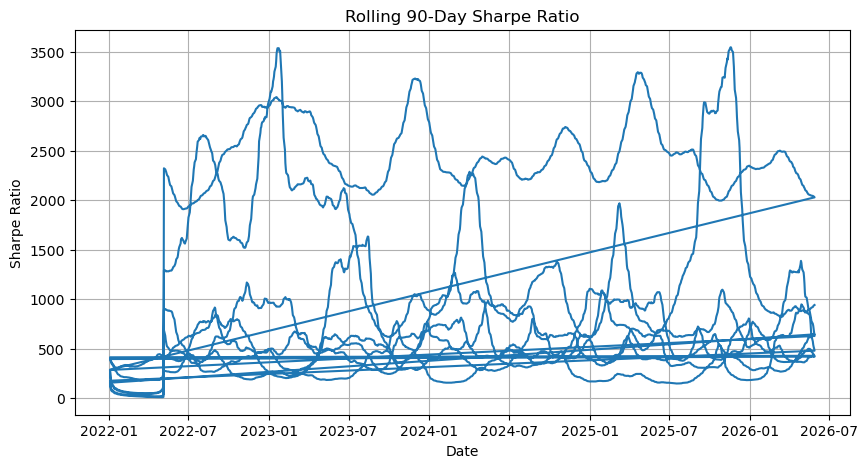

In [6]:
benchmark_df['date'] = pd.to_datetime(benchmark_df['date'])

benchmark_df['rolling_mean'] = benchmark_df['close_value'].rolling(90).mean()
benchmark_df['rolling_std'] = benchmark_df['close_value'].rolling(90).std()

benchmark_df['rolling_sharpe'] = (
    benchmark_df['rolling_mean'] /
    benchmark_df['rolling_std']
) * np.sqrt(252)

plt.figure(figsize=(10,5))
plt.plot(benchmark_df['date'], benchmark_df['rolling_sharpe'])
plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.grid(True)

plt.savefig("rolling_sharpe_chart.png")
plt.show()

In [7]:
# Investor Cohort Analysis

investor_df['transaction_date'] = pd.to_datetime(investor_df['transaction_date'])

cohort_df = investor_df.groupby('investor_id').agg({
    'transaction_date':'min',
    'amount_inr':'sum'
}).reset_index()

cohort_df['cohort_year'] = cohort_df['transaction_date'].dt.year

cohort_summary = cohort_df.groupby('cohort_year').agg({
    'investor_id':'count',
    'amount_inr':'mean'
}).reset_index()

cohort_summary.columns = [
    'cohort_year',
    'total_investors',
    'avg_investment'
]

display(cohort_summary)

,cohort_year,total_investors,avg_investment
0,2024,4803,726863.457631
1,2025,197,154595.142132


In [8]:
# SIP Continuity Analysis

sip_df = investor_df[investor_df['transaction_type'] == 'SIP'].copy()

sip_df = sip_df.sort_values(
    ['investor_id', 'transaction_date']
)

sip_df['days_gap'] = sip_df.groupby(
    'investor_id'
)['transaction_date'].diff().dt.days

sip_gap = sip_df.groupby('investor_id').agg({
    'days_gap':'mean'
}).reset_index()

sip_gap['status'] = np.where(
    sip_gap['days_gap'] > 35,
    'At Risk',
    'Active'
)

display(sip_gap.head())

print("\nAt Risk Investors:")
print((sip_gap['status'] == 'At Risk').sum())

,investor_id,days_gap,status
0,INV000001,76.0,At Risk
1,INV000002,207.0,At Risk
2,INV000003,238.0,At Risk
3,INV000004,85.4,At Risk
4,INV000005,14.0,Active



At Risk Investors:
3825


In [9]:
# Fund Recommender System

risk_choice = "High"   # Change to Low / Moderate / High

if risk_choice == "Low":
    recommended = scheme_df.sort_values(
        by="sharpe_ratio",
        ascending=False
    ).head(3)

elif risk_choice == "Moderate":
    recommended = scheme_df[
        scheme_df["risk_grade"].isin(["Moderate"])
    ].sort_values(
        by="sharpe_ratio",
        ascending=False
    ).head(3)

else:
    recommended = scheme_df.sort_values(
        by="sharpe_ratio",
        ascending=False
    ).head(3)

print("Top 3 Recommended Funds")
display(
    recommended[
        [
            "scheme_name",
            "fund_house",
            "category",
            "sharpe_ratio"
        ]
    ]
)

Top 3 Recommended Funds


,scheme_name,fund_house,category,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,7.68
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,6.18
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,5.14


In [10]:
# HHI Concentration Analysis

hhi_df = holding_df.groupby('stock_symbol')['weight_pct'].sum().reset_index()

hhi_df['weight_share'] = hhi_df['weight_pct'] / hhi_df['weight_pct'].sum()

HHI = (hhi_df['weight_share'] ** 2).sum()

print("Herfindahl-Hirschman Index (HHI):")
print(round(HHI, 4))

if HHI < 0.15:
    print("Portfolio is Diversified")
elif HHI < 0.25:
    print("Portfolio is Moderately Concentrated")
else:
    print("Portfolio is Highly Concentrated")

Herfindahl-Hirschman Index (HHI):
0.0349
Portfolio is Diversified


# Advanced Insights

### 1. Risk Analysis
The VaR and CVaR analysis identified schemes with higher downside risk. Investors should be cautious while investing in funds with high VaR values as they indicate larger potential losses.

### 2. Sharpe Ratio Trend
The rolling 90-day Sharpe Ratio showed fluctuations over time, indicating changing risk-adjusted performance across market cycles.

### 3. Investor Cohort Analysis
Investors who joined in 2025 had a significantly higher average investment amount compared to investors who joined in 2024.

### 4. SIP Continuity Analysis
A large number of investors were identified as "At Risk" due to gaps greater than 35 days between SIP transactions, indicating potential discontinuation risk.

### 5. Portfolio Concentration Analysis
The HHI score of 0.0349 indicates that portfolio holdings are well diversified and not concentrated in a few stocks.

In [11]:
import os

print(os.getcwd())

C:\Users\THARUNA SRI
